# Prediction results overview

Visualises `output_data/results/{target}/metrics.tsv` and `fold_scores.tsv` produced by `invoke run-predict`.

Run via `invoke run-notebooks` — figures are saved to `output_data/`.
One pair of figures is generated per target found under `output_data/results/`.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

OUTPUT_DIR  = Path(os.environ.get("OUTPUT_DATA_DIR", "../output_data"))
RESULTS_DIR = OUTPUT_DIR / "results"

CONDITIONS = ["eeg_only", "fmri_only", "multimodal"]
LABELS     = ["EEG only", "fMRI only", "Multimodal"]
COLORS     = ["#4C72B0", "#DD8452", "#55A868"]

target_dirs = sorted([d for d in RESULTS_DIR.iterdir() if d.is_dir() and (d / "metrics.tsv").exists()])
print(f"Found {len(target_dirs)} target(s): {[d.name for d in target_dirs]}")

Found 2 target(s): ['age', 'diagnosis']



Target: age | Task: regression | Model: ridge
 condition model       task target  mae_mean  mae_std   r2_mean   r2_std  pearson_r_mean  pearson_r_std  p_vs_chance  p_eeg_only_vs_fmri_only  p_eeg_only_vs_multimodal  p_fmri_only_vs_multimodal
  eeg_only ridge regression    age  3.342312 0.685039 -0.723324 0.974705        0.254134       0.702387     0.267327                 0.397054                  0.418559                   0.354161
 fmri_only ridge regression    age  3.564168 0.466962 -0.951827 1.149916       -0.170417       0.507137     0.722772                 0.397054                  0.418559                   0.354161
multimodal ridge regression    age  3.439005 0.779836 -0.802174 1.008372        0.288704       0.726803     0.237624                 0.397054                  0.418559                   0.354161


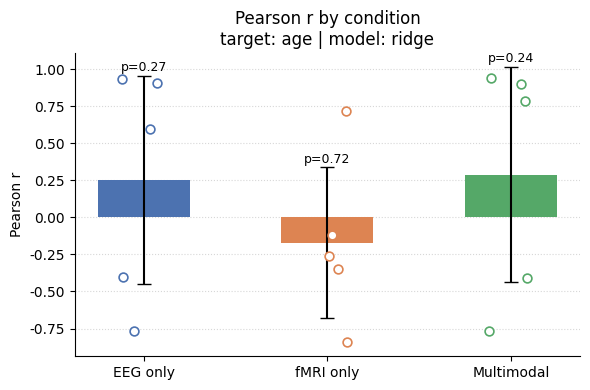

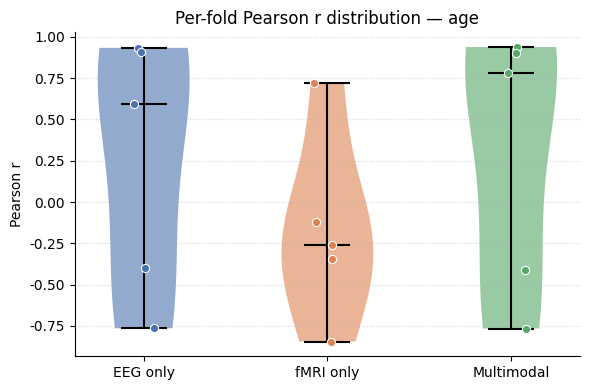


=== Per-condition ===
           Pearson r mean ± std p vs chance
Condition                                  
EEG only          0.254 ± 0.702       0.267
fMRI only        -0.170 ± 0.507       0.723
Multimodal        0.289 ± 0.727       0.238

=== Paired comparisons ===
                        p (paired t-test)
Comparison                               
EEG only vs fMRI only               0.397
EEG only vs Multimodal              0.419
fMRI only vs Multimodal             0.354

Target: diagnosis | Task: classification | Model: ridge
 condition model           task    target  balanced_accuracy_mean  balanced_accuracy_std  roc_auc_mean  roc_auc_std  p_vs_chance  p_eeg_only_vs_fmri_only  p_eeg_only_vs_multimodal  p_fmri_only_vs_multimodal
  eeg_only ridge classification diagnosis                0.616667               0.100000      0.722222     0.111111     0.089109                 0.530178                       1.0                   0.530178
 fmri_only ridge classification diagnosis       

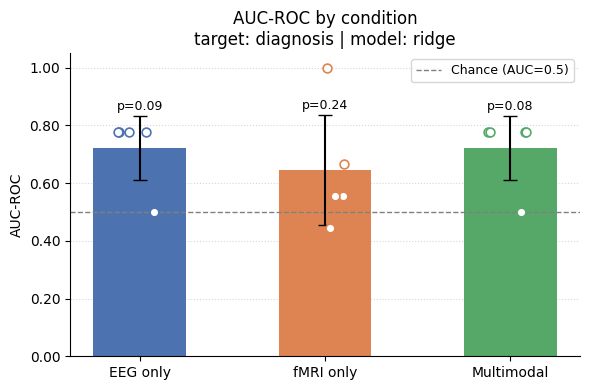

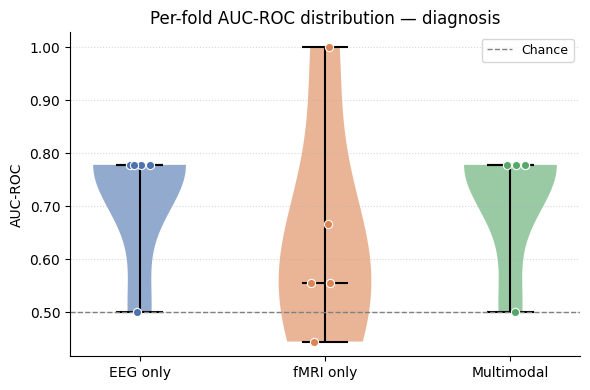


=== Per-condition ===
           AUC-ROC mean ± std p vs chance
Condition                                
EEG only        0.722 ± 0.111       0.089
fMRI only       0.644 ± 0.191       0.238
Multimodal      0.722 ± 0.111       0.079

=== Paired comparisons ===
                        p (paired t-test)
Comparison                               
EEG only vs fMRI only               0.530
EEG only vs Multimodal              1.000
fMRI only vs Multimodal             0.530


In [2]:
def fmt_p(p):
    if p < 0.001: return f"{p:.2e} ***"
    if p < 0.01:  return f"{p:.3f} **"
    if p < 0.05:  return f"{p:.3f} *"
    return f"{p:.3f}"


for target_dir in target_dirs:
    target_name = target_dir.name
    metrics = pd.read_csv(target_dir / "metrics.tsv", sep="\t")
    folds   = pd.read_csv(target_dir / "fold_scores.tsv", sep="\t")

    task = metrics["task"].iloc[0]
    model_name = metrics["model"].iloc[0]
    primary = "roc_auc" if task == "classification" else "pearson_r"
    primary_label = {"roc_auc": "AUC-ROC", "pearson_r": "Pearson r"}[primary]

    print(f"\n{'='*60}")
    print(f"Target: {target_name} | Task: {task} | Model: {model_name}")
    print(metrics.to_string(index=False))

    fold_data = {
        cond: folds[(folds["condition"] == cond) & (folds["metric"] == primary)]["value"].values
        for cond in CONDITIONS
    }
    means = [metrics.loc[metrics["condition"] == c, f"{primary}_mean"].values[0] for c in CONDITIONS]
    stds  = [metrics.loc[metrics["condition"] == c, f"{primary}_std"].values[0]  for c in CONDITIONS]

    rng = np.random.default_rng(0)
    x = np.arange(len(CONDITIONS))

    # ── bar chart ──────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(x, means, yerr=stds, width=0.5, color=COLORS,
           capsize=5, error_kw=dict(elinewidth=1.5), zorder=2)
    for i, cond in enumerate(CONDITIONS):
        jitter = rng.uniform(-0.12, 0.12, len(fold_data[cond]))
        ax.scatter(x[i] + jitter, fold_data[cond],
                   color="white", edgecolors=COLORS[i], linewidths=1.2, s=40, zorder=3)
    if task == "classification":
        ax.axhline(0.5, color="grey", linestyle="--", linewidth=1, label="Chance (AUC=0.5)")
        ax.legend(fontsize=9)
    for i, cond in enumerate(CONDITIONS):
        p = metrics.loc[metrics["condition"] == cond, "p_vs_chance"].values[0]
        stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else f"p={p:.2f}"
        ax.text(x[i], means[i] + stds[i] + 0.01, stars, ha="center", va="bottom", fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(LABELS)
    ax.set_ylabel(primary_label)
    ax.set_title(f"{primary_label} by condition\ntarget: {target_name} | model: {model_name}")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
    ax.grid(axis="y", linestyle=":", alpha=0.5, zorder=0)
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"scores_by_condition_{target_name}.png", dpi=150)
    plt.show()

    # ── violin plot ────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(6, 4))
    parts = ax.violinplot(
        [fold_data[c] for c in CONDITIONS],
        positions=x, widths=0.5, showmedians=True
    )
    for pc, color in zip(parts["bodies"], COLORS):
        pc.set_facecolor(color)
        pc.set_alpha(0.6)
    for key in ("cmedians", "cbars", "cmins", "cmaxes"):
        parts[key].set_color("black")
    for i, cond in enumerate(CONDITIONS):
        jitter = rng.uniform(-0.08, 0.08, len(fold_data[cond]))
        ax.scatter(x[i] + jitter, fold_data[cond],
                   color=COLORS[i], edgecolors="white", linewidths=0.8, s=35, zorder=3)
    if task == "classification":
        ax.axhline(0.5, color="grey", linestyle="--", linewidth=1, label="Chance")
        ax.legend(fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(LABELS)
    ax.set_ylabel(primary_label)
    ax.set_title(f"Per-fold {primary_label} distribution — {target_name}")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
    ax.grid(axis="y", linestyle=":", alpha=0.5)
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"fold_distribution_{target_name}.png", dpi=150)
    plt.show()

    # ── significance summary ───────────────────────────────────────────────────
    rows = []
    for cond, label in zip(CONDITIONS, LABELS):
        row = metrics[metrics["condition"] == cond].iloc[0]
        rows.append({
            "Condition": label,
            f"{primary_label} mean ± std": f"{row[f'{primary}_mean']:.3f} ± {row[f'{primary}_std']:.3f}",
            "p vs chance": fmt_p(row["p_vs_chance"]),
        })
    summary = pd.DataFrame(rows).set_index("Condition")
    r0 = metrics.iloc[0]
    paired = pd.DataFrame([
        {"Comparison": "EEG only vs fMRI only",   "p (paired t-test)": fmt_p(r0["p_eeg_only_vs_fmri_only"])},
        {"Comparison": "EEG only vs Multimodal",  "p (paired t-test)": fmt_p(r0["p_eeg_only_vs_multimodal"])},
        {"Comparison": "fMRI only vs Multimodal", "p (paired t-test)": fmt_p(r0["p_fmri_only_vs_multimodal"])},
    ]).set_index("Comparison")
    print("\n=== Per-condition ===")
    print(summary.to_string())
    print("\n=== Paired comparisons ===")
    print(paired.to_string())